<a href="https://colab.research.google.com/github/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar/blob/main/entornos_complejos/src/lunarlander_deepqlearning.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Deep Q-Learning en el entorno LunarLander-v3

En primer lugar instalamos las dependencias necesarias para ejecutar el código. En este caso, necesitamos instalar la biblioteca `gymnasium` y su extensión `box2d` para poder utilizar el entorno LunarLander-v3:

In [9]:
!pip install gymnasium
!pip install gymnasium[box2d]


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Realizamos los import necesarios, destacando en este caso la inclusión de `torch` para la implementación de la red neuronal que utilizaremos como función aproximadora en nuestro agente de Deep Q-Learning:

In [ ]:
#@title Copiar el repositorio.
print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
!git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
!cd EML_Carrillo_Ibarrola_Palomar/

#@title Importamos todas las clases y funciones
import sys
# Añadir los directorio fuentes al path de Python
sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar')
# Verificar que se han añadido correctamente
print(sys.path)

In [10]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
from agents import LunarAgentDeepQLearning
from utils import plot_training_metrics

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


Creamos la clase para la red neuronal que utilizaremos como función aproximadora en nuestro agente de Deep Q-Learning. Esta red tendrá una arquitectura simple con dos capas ocultas y una capa de salida que corresponde a las acciones posibles en el entorno:

También necesitaremos una clase para gestionar la memoria de experiencia, que nos permitirá almacenar las transiciones y muestrear mini-batches para el entrenamiento de la red neuronal:

In [ ]:
def train_agent(env, agent, n_episodes=2000, max_t=1000):
    scores = []                        # Lista con todas las puntuaciones
    scores_window = deque(maxlen=100)  # Cola para calcular la media movil de los ultimos 100

    for i_episode in range(1, n_episodes + 1):
        state, _ = env.reset(seed=i_episode)  # Reiniciamos el entorno con una semilla diferente cada episodio
        score = 0
        
        # Iteramos los pasos del episodio
        for t in range(max_t):
            # Solicitamos la accion al agente
            action = agent.get_action(state, agent.epsilon)
            next_state, reward, done, _, _ = env.step(action)
            
            # El agente procesa la transicion y aprende si es el momento
            agent.update(state, action, reward, done, next_state)
            
            state = next_state
            score += reward
            
            if done:
                break 
                
        # Guardamos las puntuaciones y reducimos epsilon
        scores_window.append(score)
        scores.append(score)
        agent.decay_epsilon()

        # Mostramos el progreso dinamicamente
        print(f'\rEpisodio {i_episode}\tMedia ultimos 100: {np.mean(scores_window):.2f}', end="")
        if i_episode % 100 == 0:
            print(f'\rEpisodio {i_episode}\tMedia ultimos 100: {np.mean(scores_window):.2f}')
            
    
    torch.save(agent.qnetwork_local.state_dict(), '../data/results/DeepQLearningLunarLander/checkpoint_lunar_lander.pth')
            
            
    return scores

In [12]:
import gymnasium as gym
env = gym.make('LunarLander-v3') 
state_shape = env.observation_space.shape
state_size = env.observation_space.shape[0]
number_actions = env.action_space.n
print('State shape: ', state_shape)
print('State size: ', state_size)
print('Number of actions: ', number_actions)

State shape:  (8,)
State size:  8
Number of actions:  4


In [13]:
number_episodes = 1500
maximum_number_timesteps_per_episode = 1000
epsilon_starting_value  = 1.0
epsilon_ending_value  = 0.01

discount_factor = 0.99
epsilon_decay_value = 0.995
epsilon = epsilon_starting_value
scores_on_100_episodes = deque(maxlen = 100)

env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=number_episodes)


In [14]:


agent = LunarAgentDeepQLearning( env = env, 
                                state_size = state_size, 
                                action_size = number_actions, 
                                epsilon = epsilon_starting_value, 
                                epsilon_decay = epsilon_decay_value, 
                                final_epsilon = epsilon_ending_value, 
                                discount_factor = discount_factor, 
                                seed = seed)
scores = train_agent(env, 
                     agent, 
                     n_episodes=number_episodes, 
                     max_t=maximum_number_timesteps_per_episode, 
                     )

Episodio 100	Media ultimos 100: -143.00
Episodio 200	Media ultimos 100: -104.59
Episodio 300	Media ultimos 100: -58.445
Episodio 400	Media ultimos 100: -5.020
Episodio 500	Media ultimos 100: 100.98
Episodio 600	Media ultimos 100: 161.78
Episodio 700	Media ultimos 100: 155.29
Episodio 800	Media ultimos 100: 187.10
Episodio 900	Media ultimos 100: 169.96
Episodio 1000	Media ultimos 100: 187.34
Episodio 1100	Media ultimos 100: 198.37
Episodio 1200	Media ultimos 100: 217.70
Episodio 1300	Media ultimos 100: 226.78
Episodio 1400	Media ultimos 100: 233.96
Episodio 1500	Media ultimos 100: 233.10


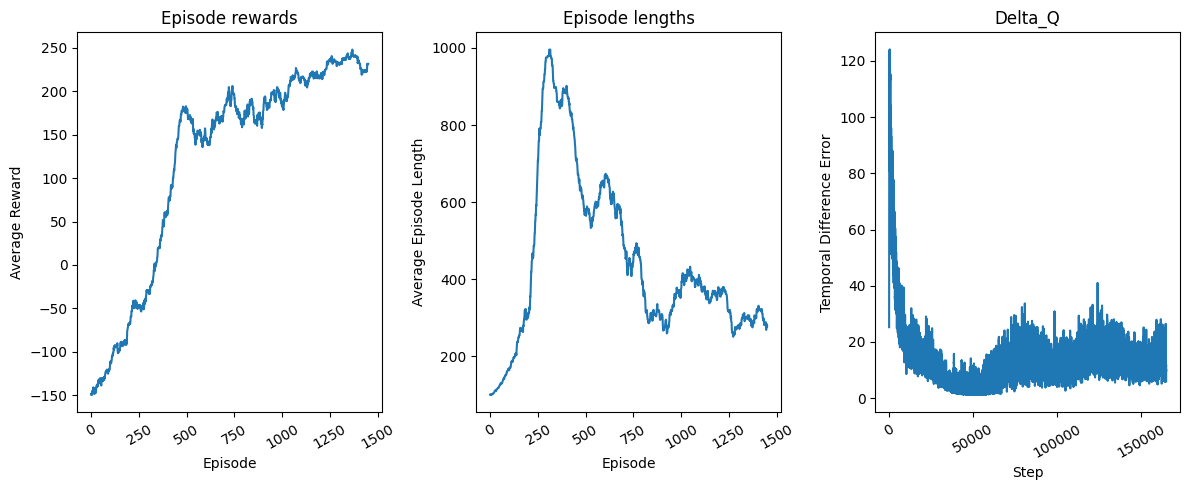

In [15]:
plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=50)

In [54]:
agent.test(n_episodes=100)


Resultados finales: 73/100 victorias.
Recompensa media real: 222.53


Probamos con un agente con una política $\epsilon$-greedy simple sin decaimiento de $\epsilon$ para ver cómo se comporta en el entorno:

In [17]:
epsilon = 0.1
final_epsilon = 0.1
epsilon_decay_value = 1.0
env2 = gym.make('LunarLander-v3')
env2 = gym.wrappers.RecordEpisodeStatistics(env2, buffer_length=number_episodes)

agent2= LunarAgentDeepQLearning( env = env2, 
                                state_size = state_size, 
                                action_size = number_actions, 
                                epsilon = epsilon, 
                                epsilon_decay = epsilon_decay_value, 
                                final_epsilon = final_epsilon, 
                                discount_factor = discount_factor, 
                                seed = seed)
scores_decay = train_agent(env2, 
                     agent2, 
                     n_episodes=number_episodes, 
                     max_t=maximum_number_timesteps_per_episode
                     )

Episodio 100	Media ultimos 100: -207.29
Episodio 200	Media ultimos 100: -146.96
Episodio 300	Media ultimos 100: -125.17
Episodio 400	Media ultimos 100: -75.474
Episodio 500	Media ultimos 100: 12.031
Episodio 600	Media ultimos 100: 149.92
Episodio 700	Media ultimos 100: 186.35
Episodio 800	Media ultimos 100: 200.76
Episodio 900	Media ultimos 100: 195.39
Episodio 1000	Media ultimos 100: 202.84
Episodio 1100	Media ultimos 100: 195.58
Episodio 1200	Media ultimos 100: 216.49
Episodio 1300	Media ultimos 100: 205.37
Episodio 1400	Media ultimos 100: 224.89
Episodio 1500	Media ultimos 100: 211.58


In [20]:
agent2.test(n_episodes=1000)


Resultados finales: 747/1000 victorias.
Recompensa media real: 214.64


In [ ]:
plot_training_metrics(env2.return_queue, env2.length_queue, agent2.training_error, rolling_length=50)


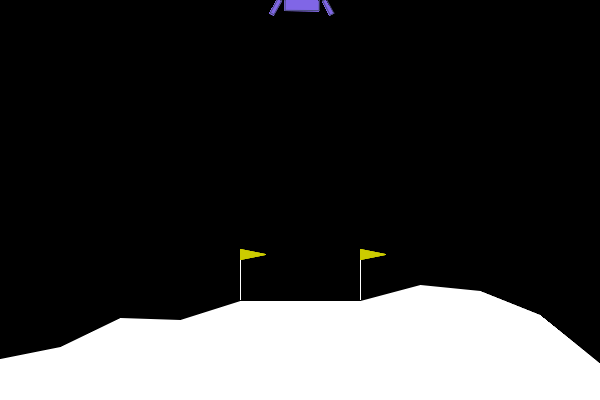

In [ ]:
import io
import base64
import imageio
from IPython.display import HTML, display
import gymnasium as gym

def generate_gif_of_model(agent, env_name, path='../data/results/DeepQLearningLunarLander/video.gif'):
    # Instanciamos el entorno para captura de fotogramas
    env = gym.make(env_name, render_mode='rgb_array')
    state, _ = env.reset()
    done = False
    frames = []
    
    while not done:
        # Extraemos y almacenamos la imagen actual
        frame = env.render()
        frames.append(frame)
        
        # Consultamos a la red neuronal sin exploración
        action = agent.get_action(state, eps=0.0) 
        
        # Ejecutamos el paso y desempaquetamos las variables
        state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated
        
    env.close()
    
    # Generamos el archivo GIF a partir de la lista de imágenes
    imageio.mimsave(path, frames, fps=30)

# Ejecutamos la función
generate_gif_of_model(agent, 'LunarLander-v3')

def show_gif(path='../data/results/DeepQLearningLunarLander/video.gif'):
    # Leemos el archivo y lo preparamos para incrustar
    try:
        gif_file = io.open(path, 'r+b').read()
        encoded = base64.b64encode(gif_file)
        
        # Mostramos la imagen codificada en base64 en la celda
        display(HTML(data='''<img src="data:image/gif;base64,{0}" alt="Lunar Lander GIF" style="height: 400px;">'''.format(encoded.decode('ascii'))))
    except FileNotFoundError:
        print("No se pudo encontrar el GIF. Revisa la ruta del directorio.")

# Mostramos el resultado
show_gif()

In [ ]:
grid_discount_factor = [0.9, 0.99, 0.999]
n_episodes =  1000
reward_histories = {}
for discount_factor in grid_discount_factor:
    print(f"Entrenando con discount factor: {discount_factor}")
    agent = LunarAgentDeepQLearning( env = env, 
                                    state_size = state_size, 
                                    action_size = number_actions, 
                                    epsilon = epsilon_starting_value, 
                                    epsilon_decay = epsilon_decay_value, 
                                    final_epsilon = epsilon_ending_value, 
                                    discount_factor = discount_factor, 
                                    seed = seed)
    scores = train_agent(env, 
                         agent, 
                         n_episodes=n_episodes, 
                         max_t=maximum_number_timesteps_per_episode, 
                         )
    reward_histories[discount_factor] = scores